##ML Guitar Effect Classification Project
CMPU-395: Machine Learning

Axel Estrada




This file contains all of the code used for my ML Final Project. It's sectioned off into the following parts:


*   Dataset Generation and Loading
*   HDF5 Shard Generation
*   Creating Train/Test Split
*   Creating the Model
*   Training and Evaluation
*   Extra code for generating more Mel-Spectrograms

Each cell will detail whether or not it needs to be run in order to properly train and/or evaluate a model.

In general, if you're not wanting to make your own files and don't have the original .wav/mel-specs, any code that involves creating shards can be skipped, as a sample shard dataset is already provided.

For the provided sample dataset, make sure that you upload it to '/contents' and that all the directories are properly named and organized. 

In [2]:
# @title Import (RUN THIS FIRST)

import torchaudio
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import torchvision.models as models
import librosa
from sklearn.model_selection import KFold

import numpy as np
import pandas as pd
import random
import math

import os
from pathlib import Path
import h5py
import shutil

import matplotlib.pyplot as plt # for visualizing mel spectrograms
from tqdm import tqdm           # for my own sanity


In [ ]:
# @title Google Drive Import (Don't run unless you're me)
# This part is for loading the shards from my synced google drive
from google.colab import files
from google.colab import drive

drive.mount('/content/drive')
!cp -r "/content/drive/Othercomputers/My Laptop/hdf5_shards" /content/

In [19]:
# @title Global Constants (Always Run)

# MEL-SPECTOGRAM GENERATOR
SAMPLE_RATE = 22050 # sampling rate in Hz
N_MELS=128          # number of mel bands to generate (i.e., the height of the mel spectrogram)
WINDOW_LENGTH=1024  # fft window size in samples (fft stands for "fast fourier transform" - this is the number of samples used to compute each column of the spectrogram)
HOP_SIZE=512        # hop length in samples

# FILE LOCATIONS
BASE_DIR = Path.cwd()
DATASETS_DIR = BASE_DIR / "Guitar_FX_Classification_Project"

MEL_SPECTROGRAMS_DIR = Path(DATASETS_DIR) / "Mel_Spectrograms"
CLEAN_RECORDINGS_DIR = Path(MEL_SPECTROGRAMS_DIR) / "Clean_Recordings_Mel_Specs" # Note: for .npy files generated from .wav files

BASE_SHARDS_DIR = Path(DATASETS_DIR) / "hdf5_shards"
MERGED_CSV_PATH = Path(DATASETS_DIR) / "merged_metadata.csv"

TRAINED_MODELS_DIR = Path(BASE_DIR) / "Trained_Models"
TRAINED_MODELS_RESULTS_DIR = Path(BASE_DIR) / "Trained_Models_Results"

MEL_FOLDER_NAME = "mel_22050_1024_512"
METADATA_NAME = "proc_settings.csv"

# TRAINING PARAMETERS
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
SHARD_SIZE = 10000      # for fragmenting HDF5 files into small chunks (number of samples per shard)
RANDOM_SEED = 42        # for reproducibility
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EFFECT_MAP = {
    "808": "overdrive",
    "TS9": "overdrive",
    "BD2": "overdrive",
    "OD1": "overdrive",
    "SD1": "overdrive",
    "MGS": "overdrive",

    "DS1": "distortion",
    "RAT": "distortion",
    "DPL": "distortion",
    "MT2": "distortion",

    "FFC": "fuzz",
    "BMF": "fuzz",
    "RBM": "fuzz",
    "VTB": "fuzz"
}

In [ ]:
# @title Colab Directories (Only run in Colab)

# clone files from repo (only do once)
#!git clone -b Final-Draft https://github.com/aestradaduda/CMPU-395-Machine-Learning-Project.git

BASE_DIR = Path.cwd() / "CMPU-395-Machine-Learning-Project"
DATASETS_DIR = Path(BASE_DIR) / "Guitar_FX_Classification_Project"

BASE_SHARDS_DIR = Path(DATASETS_DIR) / "hdf5_shards"
MERGED_CSV_PATH = Path(DATASETS_DIR) / "merged_metadata.csv"

TRAINED_MODELS_DIR = Path(BASE_DIR) / "Trained_Models"
TRAINED_MODELS_RESULTS_DIR = Path(BASE_DIR) / "Trained_Models_Results"

---

&nbsp;

# GENERATING AND LOADING DATASETS



**Dataset Snapshot (Borrowed from GUITAR-FX-DIST):**

*   **Size:** \~550k samples (~305 hours) + 550k mel spectrograms

*   **Audio Format:** WAV - 44.1kHz, 16bit, mono, -6dBFS

*   **Mel-Spectrogram Format:** NPY - 128 frequency bands, sample rate 22050Hz, window length 1024, hop size 512,

*   **Effects:** 14 between overdrive, distortion and fuzz

*   **Unprocessed recordings**
    *   624 monophonic notes

    *   420 polyphonic (2, 3 and 4 notes intervals and chords)

    *   2 guitars, with up to 2 pick-up settings and up to 3 plucking styles (finger pluck - hard, finger pluck - soft, pick)
        *   Schecter Diamond C-1 Classic
        *   Chester Stratocaster
        
    *   **Samples length:** 2 sec

## Create Merged Metadata CSV

This cell doesn't need to be run if you already have 'merged_metadata.csv' downloaded.

In [4]:
# Scans all proc_settings.csv files in each folder and 
# merges them into a single mega CSV

merged_rows = []
for major_folder in Path(MEL_SPECTROGRAMS_DIR).iterdir():
    if not major_folder.is_dir():
        continue

    audio_type = major_folder.name

    for fx_folder in major_folder.iterdir():
        if not fx_folder.is_dir():
            continue

        csv_path = fx_folder / METADATA_NAME
        if not csv_path.exists():
            continue

        df = pd.read_csv(csv_path)
        df["audio_type"] = audio_type
        df["fx"] = fx_folder.name
        merged_rows.append(df)

# Combine all CSVs into one and then save
merged_df = pd.concat(merged_rows, ignore_index=True)
merged_df.to_csv(MERGED_CSV_PATH, index=False)

print(f"Merged metadata CSV saved to:\n{MERGED_CSV_PATH}")
print(f"# rows: {len(merged_df)}")
print(f"Columns:\n{list(merged_df.columns)}")

Merged metadata CSV saved to:
c:\Users\Proff\OneDrive\Desktop\Guitar_FX_Classification_Project\merged_metadata.csv
# rows: 515005
Columns:
['filename', 'fx', 'level', 'gain', 'tone/eq1', 'tone/eq2', 'tone/eq3', 'tone/eq4', 'audio_type']


In [5]:
# @title Load Mel-Spectrograms (Always Run)
# Note: This cell loads the merged metadata CSV created in the previous cell.
# If you're working in Colab, just upload the merged_metadata.csv file

df = pd.read_csv(MERGED_CSV_PATH)

# Add mel_path column - construct paths from audio_type, fx, and filename
df["mel_path"] = df.apply(
    lambda row: str(
        Path(MEL_SPECTROGRAMS_DIR) / row["audio_type"] / row["fx"] / MEL_FOLDER_NAME / row["filename"].replace(".wav", ".npy")
    ),
    axis=1
)

# Only apply EFFECT_MAP if the effects aren't already mapped (e.g., mini dataset)
target_effects = {'distortion', 'fuzz', 'overdrive', 'clean'}
if not df['fx'].isin(target_effects).any():
    df["fx"] = df["fx"].map(EFFECT_MAP)

# drop empty rows
df = df.dropna(subset=["fx"])

# ===== ADD CLEAN RECORDINGS =====
clean_spectrograms = Path(MEL_SPECTROGRAMS_DIR) / "Clean"
mono_clean_files = list((clean_spectrograms / "Mono_Clean").glob("*.npy"))
poly_clean_files = list((clean_spectrograms / "Poly_Clean").glob("*.npy"))

clean_rows = []
for mel_file in mono_clean_files:
    clean_rows.append({
        "audio_type": "Mono_Clean",
        "fx": "clean",
        "mel_path": str(mel_file),
        "filename": mel_file.name
    })

for mel_file in poly_clean_files:
    clean_rows.append({
        "audio_type": "Poly_Clean",
        "fx": "clean",
        "mel_path": str(mel_file),
        "filename": mel_file.name
    })

df_clean = pd.DataFrame(clean_rows)
df = pd.concat([df, df_clean], ignore_index=True)

# adding a label so effects can be indexed as 0, 1, 2, or 3
# Note: This variable is referenced later for classification labels
label_to_idx = {label: i for i, label in enumerate(sorted(df["fx"].unique()))}
df["label"] = df["fx"].map(label_to_idx)

# regrouping based on audio type
# this step lets us generate .HDF5 files seperately
groups = df["audio_type"].unique()
df_audio_dict = {}
for g in groups:
    df_audio_dict[g] = df[df["audio_type"] == g].reset_index(drop=True)

print("Successfully created and updated our initial Data Frame!\n")
print(f"Total samples: {len(df)}")
print(f"Audio types: {list(groups)}")
print(f"Label mapping: {label_to_idx}")

Successfully created and updated our initial Data Frame!

Total samples: 516049
Audio types: ['Mono_Continuous', 'Mono_Discrete', 'Poly_Continuous', 'Poly_Discrete', 'Mono_Clean', 'Poly_Clean']
Label mapping: {'clean': 0, 'distortion': 1, 'fuzz': 2, 'overdrive': 3}


---

&nbsp;

# HDF5 SHARD GENERATION

Don't run any of the cells below unless you have the original mel-spectrograms downloaded and properly formatted.

In [6]:
# @title Function for Building Shards
def build_sharded_hdf5(df,                      # Dataframe
                       output_base_dir,         # base directory to save shards
                       audio_type,              # for naming and grouping shards
                       target_min_shards=None   # minimum number of shards to create (if None, uses fixed SHARD_SIZE)
                       ):
    df = df.reset_index(drop=True)

    # group by fx so we can print + name shards properly
    fx_groups = df.groupby("fx")

    for fx, fx_df in fx_groups:
        print(f"\n=== Processing FX: {fx} ({audio_type}) ===")

        fx_df = fx_df.reset_index(drop=True)

        # Determine shard size based on target_min_shards
        if target_min_shards is not None:
            # Calculate dynamic shard size to achieve target number of shards
            shard_size = max(1, len(fx_df) // target_min_shards)
        else:
            shard_size = SHARD_SIZE

        num_shards = (len(fx_df) + shard_size - 1) // shard_size

        for shard_idx in range(num_shards):
            start = shard_idx * shard_size
            end = min((shard_idx + 1) * shard_size, len(fx_df))

            shard_df = fx_df.iloc[start:end]

            shard_path = f"{output_base_dir}/{audio_type}/{audio_type}_{fx}_shard_{shard_idx:03d}.h5"

            if os.path.exists(shard_path):
                print(f"Skipping existing {shard_path}")
                continue

            if os.path.exists(shard_path):
                print(f"Skipping existing {shard_path}")
                continue

            mel_list = []
            label_list = []
            skipped = 0

            print(f"Adding mel-spectrograms to {audio_type}_{fx}_shard_{shard_idx:03d}...")

            for row in tqdm(shard_df.itertuples(index=False), total=len(shard_df)):
                path = row.mel_path

                # skip missing files
                if not os.path.exists(path):
                    skipped += 1
                    continue

                try:
                    mel = np.load(path).astype(np.float32)
                except Exception:
                    skipped += 1
                    continue

                mel_list.append(mel)
                label_list.append(row.label)

            # skip empty shard
            if len(mel_list) == 0:
                print(f"Skipped empty shard {shard_idx} (all files missing)")
                continue

            # stack into arrays
            mel_array = np.stack(mel_list)
            label_array = np.array(label_list)

            # write clean shard
            with h5py.File(shard_path, "w") as f:
                f.create_dataset("mel", data=mel_array, dtype="float32")
                f.create_dataset("label", data=label_array, dtype="int64")

            print(f"Generated {audio_type}_{fx}_shard_{shard_idx:03d}.h5 "
                  f"({len(mel_array)} samples, skipped {skipped})")

        print(f"--- Finished FX: {fx} ({audio_type}) ---")

    print(f"\nAll shards generated for {audio_type}!")

In [ ]:
# @title Folders for Shards
for audio_type in groups:
    os.makedirs(f"{BASE_SHARDS_DIR}/{audio_type}", exist_ok=True)

In [7]:
# @title Generate all HDF5 Files
for audio in df_audio_dict:
    # Use smaller shards for clean recordings to ensure 6-8 shards each
    target_shards = 6 if "Clean" in audio else None

    print(f"Generating shards for {audio}")
    build_sharded_hdf5(
        df=df_audio_dict[audio],
        output_base_dir=BASE_SHARDS_DIR,
        audio_type=audio,
        target_min_shards=target_shards
    )

Generating shards for Mono_Continuous

=== Processing FX: distortion (Mono_Continuous) ===
Skipping existing c:\Users\Proff\OneDrive\Desktop\Guitar_FX_Classification_Project\hdf5_shards/Mono_Continuous/Mono_Continuous_distortion_shard_000.h5
Skipping existing c:\Users\Proff\OneDrive\Desktop\Guitar_FX_Classification_Project\hdf5_shards/Mono_Continuous/Mono_Continuous_distortion_shard_001.h5
Skipping existing c:\Users\Proff\OneDrive\Desktop\Guitar_FX_Classification_Project\hdf5_shards/Mono_Continuous/Mono_Continuous_distortion_shard_002.h5
Skipping existing c:\Users\Proff\OneDrive\Desktop\Guitar_FX_Classification_Project\hdf5_shards/Mono_Continuous/Mono_Continuous_distortion_shard_003.h5
Skipping existing c:\Users\Proff\OneDrive\Desktop\Guitar_FX_Classification_Project\hdf5_shards/Mono_Continuous/Mono_Continuous_distortion_shard_004.h5
--- Finished FX: distortion (Mono_Continuous) ---

=== Processing FX: fuzz (Mono_Continuous) ===
Skipping existing c:\Users\Proff\OneDrive\Desktop\Guitar_

---

&nbsp;

# CREATING TRAIN/TEST SPLITS

Below are functions for generating individual train/test splits with the hdf5 shards we've generated above. 

The first two functions can be run on their own for a single test loop. 

For more rigorous testing, there's a k-folds function in the next section, which implements the first two functions. 

The general process goes as follows:
1. Split up the HDF5 shards into training split and test split
2. Seperately load train/test splits into Spectrogram_Dataset(), which processes our mel-specs and saves them onto train/test datasets
3. Pass these datasets to our dataloader class so that we can properly train our models

In [53]:
# @title Train/Test Split Function (Always Run)

# Scans all HDF5 files across all folders and creates train/test split.
# Returns lists of file paths for training and testing.
# NOTE: This function generates splits based on individual files, 
# not by individual recordings or effects. 
def create_hdf5_train_test_split(hdf5_base_dir, test_size, random_state):

    random.seed(random_state)
    hdf5_files = []
    base_path = Path(hdf5_base_dir)

    # Scan all subdirectories for HDF5 files
    for audio_type_folder in base_path.iterdir():
        if audio_type_folder.is_dir():
            for h5_file in audio_type_folder.glob("*.h5"):
                hdf5_files.append(str(h5_file))

    print(f"\n=== Creating HDF5 Train/Test Split ===")
    print(f"Total HDF5 files found: {len(hdf5_files)}")

    # Shuffle and split
    random.shuffle(hdf5_files)
    split_idx = int(len(hdf5_files) * (1 - test_size))

    train_files = hdf5_files[:split_idx]
    test_files = hdf5_files[split_idx:]

    # high key remove all the print statements and just return the lists of files
    print(f"Training files: {len(train_files)} ({len(train_files) / len(hdf5_files) * 100:.1f}%)")
    print(f"Testing files: {len(test_files)} ({len(test_files) / len(hdf5_files) * 100:.1f}%)")

    # Print breakdown by category
    print(f"\n--- Files by Category ---")
    categories = {}
    for file in hdf5_files:
        # Extract category from filename (e.g., "Mono_Continuous_distortion_shard_000.h5")
        parts = file.split("_shard_")[0].split(os.sep)[-1]
        categories[parts] = categories.get(parts, 0) + 1

    for cat, count in sorted(categories.items()):
        print(f"{cat}: {count}")

    print(f"--- End Split ---\n")

    return train_files, test_files

In [54]:
# @title Spectrogram Dataset Class (Always Run)

# Dataset class that goes through our HDF5 files by processing the mel spectrograms and labels during training and testing.
class Spectrogram_Dataset(Dataset):

    def __init__(self, h5_file_list):
        self.h5_files = h5_file_list
        self.file_info = []  # List of (file_path, num_samples)
        self.total_samples = 0

        # Pre-scan files to know how many samples each contains
        for h5_file in self.h5_files:
            try:
                with h5py.File(h5_file, "r") as f:
                    num_samples = len(f["mel"])
                    self.file_info.append((h5_file, num_samples))
                    self.total_samples += num_samples

            except Exception as e:
                print(f"Warning: Could not read {h5_file}: {e}")

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        # Find which file this index belongs to
        cumulative = 0
        for h5_file, num_samples in self.file_info:
            if idx < cumulative + num_samples:
                local_idx = idx - cumulative

                # Load from file
                with h5py.File(h5_file, "r") as f:
                    x = f["mel"][local_idx].astype(np.float32)
                    y = f["label"][local_idx]

                # Preprocess mel spectrogram
                x = np.log1p(x) # log scaling; compresses range so that louder sounds don't dominate
                x = (x - x.mean()) / (x.std() + 1e-6) # Normalization; zero mean and unit variance

                # Convert to tensors
                x = torch.tensor(x).float().unsqueeze(0)  # Add channel dimension
                y = torch.tensor(y).long()

                return x, y

            cumulative += num_samples

        raise IndexError(f"Index {idx} out of range for dataset with {self.total_samples} samples")


In [79]:
# @title Creating Our Splits (Run if you're not using k-folds)
# Note: The split percentage will vary based on the number of HDF5 shard files uploaded,
# but should roughly fit the percentage set
train_files, test_files = create_hdf5_train_test_split(
    hdf5_base_dir=BASE_SHARDS_DIR,
    test_size=0.2,
    random_state=RANDOM_SEED+1
)


=== Creating HDF5 Train/Test Split ===
Total HDF5 files found: 72
Training files: 57 (79.2%)
Testing files: 15 (20.8%)

--- Files by Category ---
Mono_Clean_clean: 6
Mono_Continuous_distortion: 5
Mono_Continuous_fuzz: 5
Mono_Continuous_overdrive: 7
Mono_Discrete_distortion: 5
Mono_Discrete_fuzz: 4
Mono_Discrete_overdrive: 4
Poly_Clean_clean: 6
Poly_Continuous_distortion: 5
Poly_Continuous_fuzz: 5
Poly_Continuous_overdrive: 7
Poly_Discrete_distortion: 5
Poly_Discrete_fuzz: 3
Poly_Discrete_overdrive: 5
--- End Split ---



In [101]:
# @title Create DataLoaders from HDF5 Files (Run if you're not using k-folds, or want to use visualize_predictions() function)
# This code generates the actual splits for training and testing by creating Dataset objects and then DataLoaders.
train_dataset = Spectrogram_Dataset(train_files)
test_dataset = Spectrogram_Dataset(test_files)

print(f"Train dataset size: {len(train_dataset)} samples")
print(f"Test dataset size: {len(test_dataset)} samples")

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,     # randomizing ordering
                          num_workers=0,    # set to 0 for HDF5 (compatibility issue)
                          pin_memory=True)  # speeds up transfer to GPU if True

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         num_workers=0,
                         pin_memory=True)

Train dataset size: 406582 samples
Test dataset size: 85377 samples




---

&nbsp;

# LOADING OUR MODELs

Below are the available models I used for testing. The two models tested for this project were a simple VGG network and a ResNet-18 network.

The simple VGG architecture consists of:
* 4 convolutional blocks (Conv2d + ReLU + MaxPool2d)
* Adaptive average pooling to ensure consistent output size regardless of input dimensions
* Flattening and fully connected layers for classification

This is a smaller version of VGG to fit our dataset and computational constraints.

The ResNet-18 Model consists of:
* 18 residual blocks, each consisting of: 
*   two convolutional layers, 
*   a batch normalization function, 
*   and a ReLU activation function. 

The key feature of this architecture is the skip connections at each block, which bypass one or more layers (GeeksforGeeks, 2025). 

The model was modified to work with our dataset and categories, so the first convolutional layer was changed from a 3-channel input to a single channel, and the final layer mapped onto our labels. 

In [ ]:
# @title Simple-VGG Model 

class simpleVGG(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # 4 conv blocks / flatten / linear / softmax
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                stride=1,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Adaptive pooling to ensure consistent output size
        # regardless of input dimensions
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # flatten and linear layers for classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),  # 128 channels * 4x4 spatial dims
            nn.ReLU(),
            nn.Linear(256, num_classes)
            )

    def forward(self, input_data):
        x = self.conv1(input_data)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.adaptive_pool(x)  # Normalize spatial dimensions to 4x4
        logits = self.classifier(x)

        # Don't need if we're using Cross_Entropy_Loss()
        # predictions = self.softmax(logits)
        return logits

# creating model
MODEL = simpleVGG(num_classes=len(EFFECT_MAP))
MODEL_SAVE_PATH = "guitar_fx_classifier_simpleVGG_4classes_round2.pth"


In [49]:
# @title ResNet-18 Model for Mel-Spectrograms

MODEL = models.resnet18(pretrained=False)

# Modify first convolution to accept 1-channel input (mel-spectrograms) instead of 3 (RGB)
MODEL.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Replace final FC layer for guitar effect classification (now 4 classes: overdrive, distortion, fuzz, clean)
MODEL.fc = nn.Linear(MODEL.fc.in_features, len(label_to_idx))

MODEL_SAVE_PATH = "ResNet18_no-pretraining_model2.pth"

c:\Users\Proff\guitar_cuda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Proff\guitar_cuda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [50]:
# @title Load Model Parameters if they Exists (Optional)

# Alternaively, you can just run this cell to load the model if it already exists
# It will print out the model info and parameters so you can verify it's correct

# Available models from repo:
# simpleVGG_4classes_round2.pth
# simpleVGG_4classes_round1.pth
# ResNet18_no-pretraining_round2.pth
# ResNet18_no-pretraining_round1.pth
Model_name = "ResNet18_no-pretraining_round2.pth"
Model_path = TRAINED_MODELS_DIR / Model_name

if os.path.exists(Model_path):
    print(f"Loading existing model from {Model_name}...")
    checkpoint = torch.load(Model_path, map_location=DEVICE)
    MODEL.load_state_dict(checkpoint["state_dict"])

    print("Model info:")
    model_params = checkpoint.get("model_params", {})

    labels = model_params.get("label_to_idx", label_to_idx)
    effects_map = model_params.get("effect_map", EFFECT_MAP)
    architecture = model_params.get("architecture", None)
    epoch = checkpoint.get("epoch", "unknown")

    print(f"  labels: {labels}")
    print(f"  effects map: {effects_map}")
    print(f"  epochs: {epoch}")

    if architecture is not None:
        print(f"  architecture: {architecture}")

    total_params = sum(p.numel() for p in MODEL.parameters())
    print(f"  total parameters: {total_params:,}")

else:
    print(f"No existing model found at {Model_name}...")

Loading existing model from ResNet18_no-pretraining_round2.pth...
Model info:
  labels: {'clean': 0, 'distortion': 1, 'fuzz': 2, 'overdrive': 3}
  effects map: {'808': 'overdrive', 'TS9': 'overdrive', 'BD2': 'overdrive', 'OD1': 'overdrive', 'SD1': 'overdrive', 'MGS': 'overdrive', 'DS1': 'distortion', 'RAT': 'distortion', 'DPL': 'distortion', 'MT2': 'distortion', 'FFC': 'fuzz', 'BMF': 'fuzz', 'RBM': 'fuzz', 'VTB': 'fuzz'}
  epochs: 10
  architecture: ResNet18
  total parameters: 11,172,292


C:\Users\Proff\AppData\Local\Temp\ipykernel_37924\2771061336.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(Model_path, map_location=DEVICE)


In [52]:
# @title Instantiate Loss Function + Optimizer (Always Run)
loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(MODEL.parameters(),
                             lr=LEARNING_RATE)

# Setting up model to device
MODEL = MODEL.to(DEVICE)
print(f"Using {DEVICE} device")


Using cuda device


---

&nbsp;

# MODEL TRAINING FUNCTIONS

Below are the functions for training our model based on the hyperparameters we set at the beginning, ahd the train/test splits we generated perviously. 

train_one_epoch() is the core training loop for one epoch. It iterates through the training DataLoader, processes each batch, and updates the model weights using backpropagation. 
It also tracks the average loss and accuracy for the epoch. It returns a dictionary of epoch, training loss, and training accuracy. 

train() is the loop for training our model across multiple epochs. 

After each epoch, it goes through the validation set (if provided) to evaluate performance and track metrics. It returns a list of dictionaries containing the recorded metrics for each epoch, which can be used for further analysis or visualization later on.

In [11]:
# @title Training One Epoch + Training Loop Function (Always Run)

def train_one_epoch(model, train_loader, loss_fn, optimizer, device, epoch_num):
    model.train()  # Set model to training mode
    total_samples = 0
    epoch_loss = 0.0
    correct = 0

    print(f"\n--- Epoch {epoch_num} Training ---")

    # Loop 
    with tqdm(total=len(train_loader), desc=f"Epoch {epoch_num}", unit="batch") as pbar: # Progress bar
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            # Move data to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            predictions = model(inputs)
            loss = loss_fn(predictions, targets)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track metrics
            epoch_loss += loss.item()
            total_samples += inputs.size(0)

            # Track accuracy
            _, predicted = torch.max(predictions.data, 1)
            correct += (predicted == targets).sum().item()

            # Update progress bar
            pbar.update(1)
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / max(len(train_loader), 1)
    accuracy = 100 * correct / total_samples
    print(f"Epoch {epoch_num} - Avg Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}% | Total Samples: {total_samples}")
    
    return {"epoch": epoch_num, "train_loss": avg_loss, "train_accuracy": accuracy}

In [12]:
# @title Full Training Loop (Always Run)

def train(model, 
          train_loader,     # DataLoader for training data
          loss_fn, 
          optimizer, 
          device, 
          n_epochs, 
          val_loader=None): # Optional DataLoader for validation data (used to track performance after each epoch)
   
    print("\n" + "="*50)
    print("MODEL TRAINING INITIALIZED")
    print("="*50)

    # Print model parameters
    total_params = sum(p.numel() for p in model.parameters())

    print(f"\n--- Model Parameters ---")
    print(f"Total Parameters: {total_params:,}")
    print(f"Device: {device}")
    print(f"Batch Size: {BATCH_SIZE}")
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Optimizer: {optimizer.__class__.__name__}")
    print(f"Loss Function: {loss_fn.__class__.__name__}")
    print(f"Total Epochs: {n_epochs}")
    print(f"Total Batches per Epoch: {len(train_loader)}")
    if val_loader:
        print(f"Validation batches: {len(val_loader)}")

    print("\n" + "="*50 + "\n")

    all_metrics = []
    
    # Loop
    for epoch in range(n_epochs):
        train_metrics = train_one_epoch(model, train_loader, loss_fn, optimizer, device, epoch + 1)
        
        # Add validation metrics if val_loader provided
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                
                # this loop checks the model's performance on the validation set after each epoch of training,
                # calculating the average loss and accuracy across all validation batches.
                for inputs, targets in val_loader:
                    inputs = inputs.to(device)
                    targets = targets.to(device)
                    
                    outputs = model(inputs)
                    loss = loss_fn(outputs, targets)
                    
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += targets.size(0)
                    val_correct += (predicted == targets).sum().item()
            
            # performing calculations
            val_loss /= max(len(val_loader), 1)
            val_accuracy = 100 * val_correct / val_total
            
            # storing validation metrics in the same dictionary as training metrics for easy tracking
            train_metrics["val_loss"] = val_loss
            train_metrics["val_accuracy"] = val_accuracy
            
            print(f"  Loss: {val_loss:.4f} | Accuracy: {val_accuracy:.2f}%")
        
        all_metrics.append(train_metrics)
        print("-" * 50)

    print("\n" + "="*50)
    print("Training Completed!")
    print("="*50 + "\n")
    
    # here we return the list of dictionaries containing the recorded metrics for each epoch, 
    # which can be used for further analysis or visualization later on.
    return all_metrics

In [ ]:
# @title Finally, we can start training our model! (Optional)

# This will actually train the model using the training loop we defined above. 
# Don't be surprised if it takes a while depending on your hardware and the number of epochs you set.
MODEL_metrics = train(MODEL, train_loader, loss_fn, optimizer, DEVICE, EPOCHS)

# print final metrics
final_metrics = MODEL_metrics[-1]
print(f"\nFinal Training Loss: {final_metrics['train_loss']:.4f}")
print(f"Final Training Accuracy: {final_metrics['train_accuracy']:.2f}%")

if "val_loss" in final_metrics:
    print(f"Final Validation Loss: {final_metrics['val_loss']:.4f}")
    print(f"Final Validation Accuracy: {final_metrics['val_accuracy']:.2f}%")

In [ ]:
# @title Saving Our Model (Optional)
# NOTE: Be careful when running this cell. 
# It will overwrite the existing model checkpoint if it exists.

# Create a checkpoint with model state and metadata
checkpoint = {
    'epoch': EPOCHS,
    'state_dict': MODEL.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss_fn,
    'model_params': {
        'num_classes': len(EFFECT_MAP),
        'label_to_idx': label_to_idx,
        'effect_map': EFFECT_MAP,
        'architecture': 'simpleVGG'  # either 'simpleVGG' or 'ResNet18' depending on which model you used
    }
}

# Save the checkpoint
torch.save(checkpoint, MODEL_SAVE_PATH)
print(f"Model checkpoint saved to {MODEL_SAVE_PATH}")

Model checkpoint saved to guitar_fx_classifier_simpleVGG_4classes_round2.pth


In [13]:
# @title Model Evaluation Function (Always Run)

# This is a simple function for evaluating the model on the test set. 
# It calculates the overall accuracy and prints out the results.
def evaluate(model, test_loader, device):
    
    model.eval()
    correct = 0
    total = 0

    print(f"\n--- Evaluating on Test Set ---")

    with torch.no_grad(): # no need to track gradients during evaluation
        with tqdm(total=len(test_loader), desc="Evaluating", unit="batch") as pbar: # progress bar 
            for inputs, targets in test_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)

                # Get predictions
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)

                # Count correct predictions
                total += targets.size(0)
                correct += (predicted == targets).sum().item()

                pbar.update(1)

    accuracy = 100 * correct / total
    print(f"\n==== Test Set Results ====")
    print(f"Total Samples: {total}")
    print(f"Correct Predictions: {correct}")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"=========================\n")

    return accuracy

In [ ]:
# @title Run Single Evaluation (Optional)
test_accuracy = evaluate(MODEL, test_loader, DEVICE)

---

# K-FOLDS CROSS VALIDATION

As an extention of the train/test functions above, we also have k-folds cross-validation to test across multiple splits of the data. 

This function will store the training/validation results between epochs onto a .csv, so that we can plot and compare results later.

In [10]:
# @title K-Folds Cross Validation (Optional)

def kfolds_cross_validation(k=5,                        # number of folds                      
                            epochs=10,                   
                            batch_size=128,              
                            model_class=None,           # Model we want to train
                            loss_fn=None,                
                            optimizer_class=None,        
                            learning_rate=0.001,         
                            output_csv=                 # Path to save results CSV
                                "kfolds_results.csv", 
                            random_state=RANDOM_SEED):  # Random seed for reproducibility

    random.seed(random_state)       # for python random module reproducibility
    np.random.seed(random_state)    # for NumPy reproducibility
    torch.manual_seed(random_state) # for PyTorch reproducibility
    
    # basic checks
    if loss_fn is None:
        print("Error: No loss function provided.")
        return
    if optimizer_class is None:
        print("Error: No optimizer class provided.")
        return
    if model_class is None:
        print("Error: No model class provided.")
        return
    
    # generate train/test split based on files 
    train_files, test_files = create_hdf5_train_test_split(
        hdf5_base_dir=BASE_SHARDS_DIR,
        test_size=0.0,  # We'll do our own split with KFold
        random_state=random_state
    )
    hdf5_files = train_files + test_files # Combine all files for k-fold splitting
    
    print(f"\n{'='*50}")
    print(f"K-FOLDS CROSS VALIDATION ({k}-FOLDS)")
    print(f"{'='*50}")
    print(f"Total HDF5 files: {len(hdf5_files)}")
    print(f"Epochs per fold: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Loss function: {loss_fn.__class__.__name__}")
    print(f"Optimizer: {optimizer_class.__name__}")
    print(f"Learning rate: {learning_rate}\n")
    
    # Initialize k-fold splitter
    kfold = KFold(n_splits=k, shuffle=True, random_state=random_state)
    
    all_metrics = []
    fold_accuracies = []
    
    # Iterate through folds
    for fold_num, (train_idx, val_idx) in enumerate(kfold.split(hdf5_files), 1):
        print(f"\n{'─'*50}")
        print(f"FOLD {fold_num}/{k}")
        print(f"{'─'*50}")
        
        # Split files into training and validation sets
        train_files = [hdf5_files[i] for i in train_idx]
        val_files = [hdf5_files[i] for i in val_idx]
        
        print(f"Train files: {len(train_files)} | Val files: {len(val_files)}")
        
        # Create datasets + loaders
        train_dataset = Spectrogram_Dataset(train_files)
        val_dataset = Spectrogram_Dataset(val_files)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        
        # Initialize model
        if model_class is None:
            return "Error: model_class must be provided for k-folds cross validation"
        else:
            fold_model = model_class
        
        # Move model to device
        fold_model = fold_model.to(DEVICE)
        
        # Create optimizer for this fold with the provided optimizer class and learning rate
        fold_optimizer = optimizer_class(fold_model.parameters(), lr=learning_rate)
        
        # Train fold and collect metrics with the provided loss function
        # NOTE: we don't provide a validation loader to the training function 
        # since k-folds evaluates separately after each training
        fold_metrics = train(fold_model, train_loader, loss_fn, fold_optimizer, DEVICE, epochs, val_loader=None)
        
        # Evaluate on validation set after training
        fold_validation_accuracy = evaluate(fold_model, val_loader, DEVICE)
        
        # Add fold number and final validation accuracy to each epoch's metrics
        for metric in fold_metrics:
            metric['fold'] = fold_num
            metric['val_accuracy'] = fold_validation_accuracy
        
        all_metrics.extend(fold_metrics)
        fold_accuracies.append(fold_validation_accuracy)
        
        print(f"\nFold {fold_num} Final Validation Accuracy: {fold_validation_accuracy:.2f}%")
    
    # Convert to DataFrame and save to .csv
    results_df = pd.DataFrame(all_metrics)
    results_df.to_csv(output_csv, index=False) # saves to current directory by default
    
    # Print summary results
    print(f"\n{'='*50}")
    print(f"K-FOLDS CROSS VALIDATION COMPLETE")
    print(f"Results saved to: {output_csv}")
    print(f"{'='*50}")
    
    print(f"\nFold Accuracies:")
    for i, acc in enumerate(fold_accuracies, 1):
        print(f"  Fold {i}: {acc:.2f}%")
        
    print(f"\nMean Accuracy: {np.mean(fold_accuracies):.2f}% (+/- {np.std(fold_accuracies):.2f}%)")
    print(f"{'='*50}\n")
    
    return results_df

In [ ]:
# @title Run K-Folds Cross Validation (Optional)

# This will run the entire k-folds cross validation process using the parameters and model you defined above.
# This will take even longer than regular training, so be prepared for long wait times if you set a high number of epochs or folds.
kfolds_results = kfolds_cross_validation(
    k=5,                          
    epochs=EPOCHS,                
    batch_size=BATCH_SIZE,        
    model_class=MODEL,            
    loss_fn=loss_fn,                  
    optimizer_class=torch.optim.Adam, 
    learning_rate=LEARNING_RATE,       
    output_csv="kfolds-simpleVGG-model2.csv",
    random_state=RANDOM_SEED+1
)


=== Creating HDF5 Train/Test Split ===
Total HDF5 files found: 72
Training files: 72 (100.0%)
Testing files: 0 (0.0%)

--- Files by Category ---
Mono_Clean_clean: 6
Mono_Continuous_distortion: 5
Mono_Continuous_fuzz: 5
Mono_Continuous_overdrive: 7
Mono_Discrete_distortion: 5
Mono_Discrete_fuzz: 4
Mono_Discrete_overdrive: 4
Poly_Clean_clean: 6
Poly_Continuous_distortion: 5
Poly_Continuous_fuzz: 5
Poly_Continuous_overdrive: 7
Poly_Discrete_distortion: 5
Poly_Discrete_fuzz: 3
Poly_Discrete_overdrive: 5
--- End Split ---


K-FOLDS CROSS VALIDATION (5-FOLDS)
Total HDF5 files: 72
Epochs per fold: 10
Batch size: 128
Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


──────────────────────────────────────────────────
FOLD 1/5
──────────────────────────────────────────────────
Train files: 57 | Val files: 15

MODEL TRAINING INITIALIZED

--- Model Parameters ---
Total Parameters: 625,294
Device: cuda
Batch Size: 128
Learning Rate: 0.001
Optimizer: Adam
Loss Function: CrossEn

Epoch 1: 100%|██████████| 3132/3132 [06:51<00:00,  7.60batch/s, loss=0.0815]


Epoch 1 - Avg Loss: 0.2572 | Accuracy: 89.14% | Total Samples: 400875
--------------------------------------------------

--- Epoch 2 Training ---


Epoch 2: 100%|██████████| 3132/3132 [06:48<00:00,  7.66batch/s, loss=0.0987]


Epoch 2 - Avg Loss: 0.1010 | Accuracy: 95.20% | Total Samples: 400875
--------------------------------------------------

--- Epoch 3 Training ---


...

Epoch 9 - Avg Loss: 0.0751 | Accuracy: 95.57% | Total Samples: 386323
--------------------------------------------------

--- Epoch 10 Training ---


Epoch 10: 100%|██████████| 3019/3019 [06:34<00:00,  7.66batch/s, loss=0.2529]


Epoch 10 - Avg Loss: 0.0758 | Accuracy: 95.57% | Total Samples: 386323
--------------------------------------------------

Training Completed!


--- Evaluating on Test Set ---


Evaluating: 100%|██████████| 826/826 [01:26<00:00,  9.51batch/s]


==== Test Set Results ====
Total Samples: 105636
Correct Predictions: 101379
Accuracy: 95.97%


Fold 5 Final Validation Accuracy: 95.97%

K-FOLDS CROSS VALIDATION COMPLETE
Results saved to: kfolds-simpleVGG-model2.csv

Fold Accuracies:
  Fold 1: 86.62%
  Fold 2: 96.50%
  Fold 3: 80.73%
  Fold 4: 85.90%
  Fold 5: 95.97%

Mean Accuracy: 89.14% (+/- 6.14%)



# Plotting our Training Metrics (Optional)

Below is a function for plotting training loss and accuracy from a results DataFrame. This is designed to work with single train/test splits or k-folds cross validation.

For results_df, the function expects the df to at least have columns labeled 'epoch', 'train_loss', and 'train_accuracy'.
If plotting k-folds results between folds, the function also expects columns labeled 'fold' and 'val_accuracy', so that it can graph the validation accuracy after each fold.   

In [113]:
def plot_training_metrics(results_df,       # DataFrame with training metrics
                          title_prefix=""): # String to prepend to plot titles (e.g., "K-Folds: ")

    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Check if this is k-folds data (should have 'fold' column)
    has_folds = 'fold' in results_df.columns
    
    ### MULTIPLE TRAINING RUNS ###
    if has_folds:
        # Plot loss per fold
        for fold in sorted(results_df['fold'].unique()):
            fold_data = results_df[results_df['fold'] == fold]
            axes[0].plot(fold_data['epoch'], fold_data['train_loss'], label=f'Fold {fold}', alpha=0.7)

        # setting up our loss graph
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title(f'{title_prefix}Training Loss per Fold')
        axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        axes[0].grid(True, alpha=0.3)
        
        # Auto-zoom loss-axis to data range
        loss_vals = results_df['train_loss'].values
        loss_min, loss_max = loss_vals.min(), loss_vals.max()
        loss_range = loss_max - loss_min
        padding = max(0.1 * loss_range, 0.01)  # 10% padding or 0.01, whichever is larger
        axes[0].set_ylim(loss_min - padding, loss_max + padding)

        # Plot accuracy per fold
        for fold in sorted(results_df['fold'].unique()):
            fold_data = results_df[results_df['fold'] == fold]
            axes[1].plot(fold_data['epoch'], fold_data['train_accuracy'], label=f'Fold {fold}', alpha=0.7) 

        # setting up our accuracy graph
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_title(f'{title_prefix}Training Accuracy per Fold')
        axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        axes[1].grid(True, alpha=0.3)
        
        # Auto-zoom accuracy-axis to data range
        acc_vals = results_df['train_accuracy'].values
        acc_min, acc_max = acc_vals.min(), acc_vals.max()
        acc_range = acc_max - acc_min
        padding = max(0.05 * acc_range, 1)  # 5% padding or 1%, whichever is larger
        axes[1].set_ylim(max(0, acc_min - padding), min(100, acc_max + padding))
    
    ### SINGLE TRAINING RUN ###
    else:
        # Single split data
        axes[0].plot(results_df['epoch'], results_df['train_loss'], label='Training Loss', linewidth=2, color='#1f77b4')
        
        if 'val_loss' in results_df.columns:
            axes[0].plot(results_df['epoch'], results_df['val_loss'], label='Validation Loss', linewidth=2, color="#ff7f0e", linestyle='--')
        
        # setting up our loss graph
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title(f'{title_prefix}Training Loss')
        axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        axes[0].grid(True, alpha=0.3)
        
        # Auto-zoom loss axis to data range
        loss_vals = results_df['train_loss'].values
        loss_min, loss_max = loss_vals.min(), loss_vals.max()
        loss_range = loss_max - loss_min
        padding = max(0.1 * loss_range, 0.01)
        axes[0].set_ylim(loss_min - padding, loss_max + padding)

        axes[1].plot(results_df['epoch'], results_df['train_accuracy'], label='Training Accuracy', linewidth=2, color='#1f77b4')
        if 'val_accuracy' in results_df.columns:
            axes[1].plot(results_df['epoch'], results_df['val_accuracy'], label='Validation Accuracy', linewidth=2, color="#ff7f0e", linestyle='--')
        
        # setting up our accuracy graph
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_title(f'{title_prefix}Training Accuracy')
        axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        axes[1].grid(True, alpha=0.3)
        
        # Auto-zoom accuracy axis to data range
        acc_vals = results_df['train_accuracy'].values
        acc_min, acc_max = acc_vals.min(), acc_vals.max()
        acc_range = acc_max - acc_min
        padding = max(0.05 * acc_range, 1)
        axes[1].set_ylim(max(0, acc_min - padding), min(100, acc_max + padding))
    
    plt.tight_layout()
    plt.show()

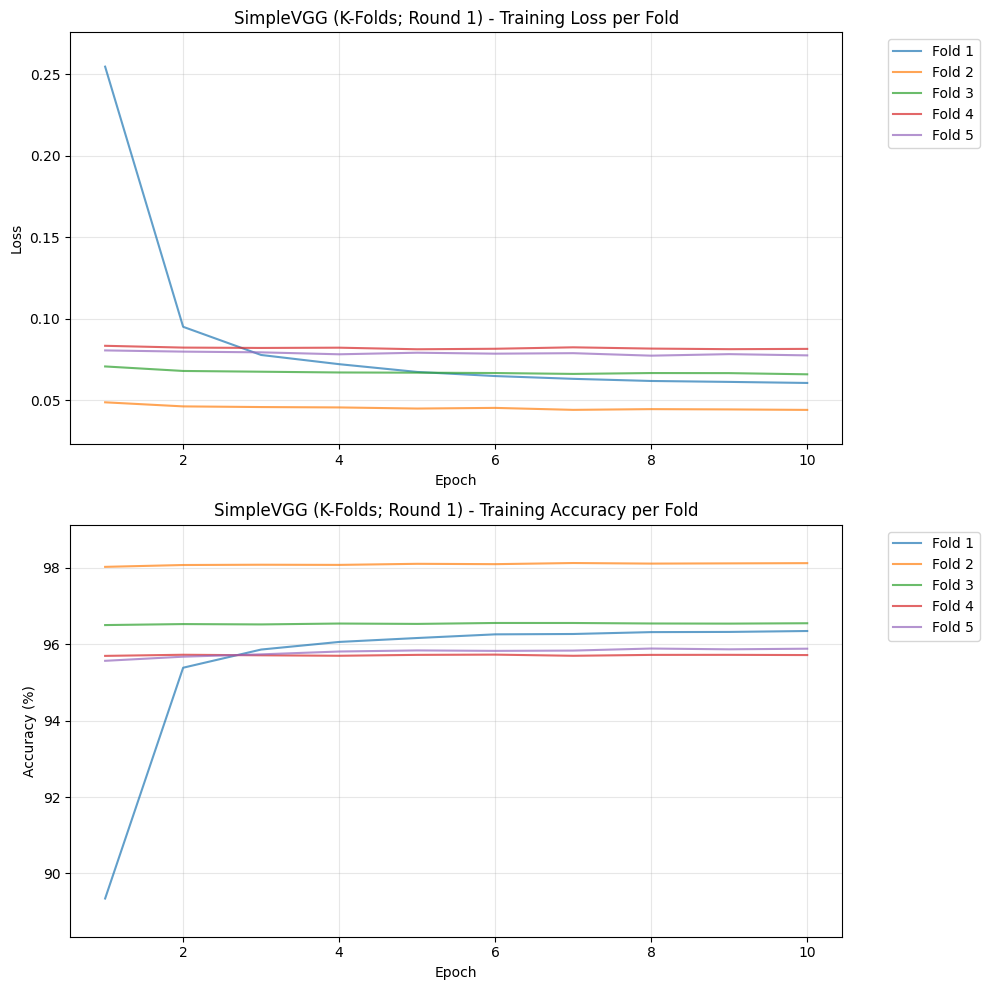

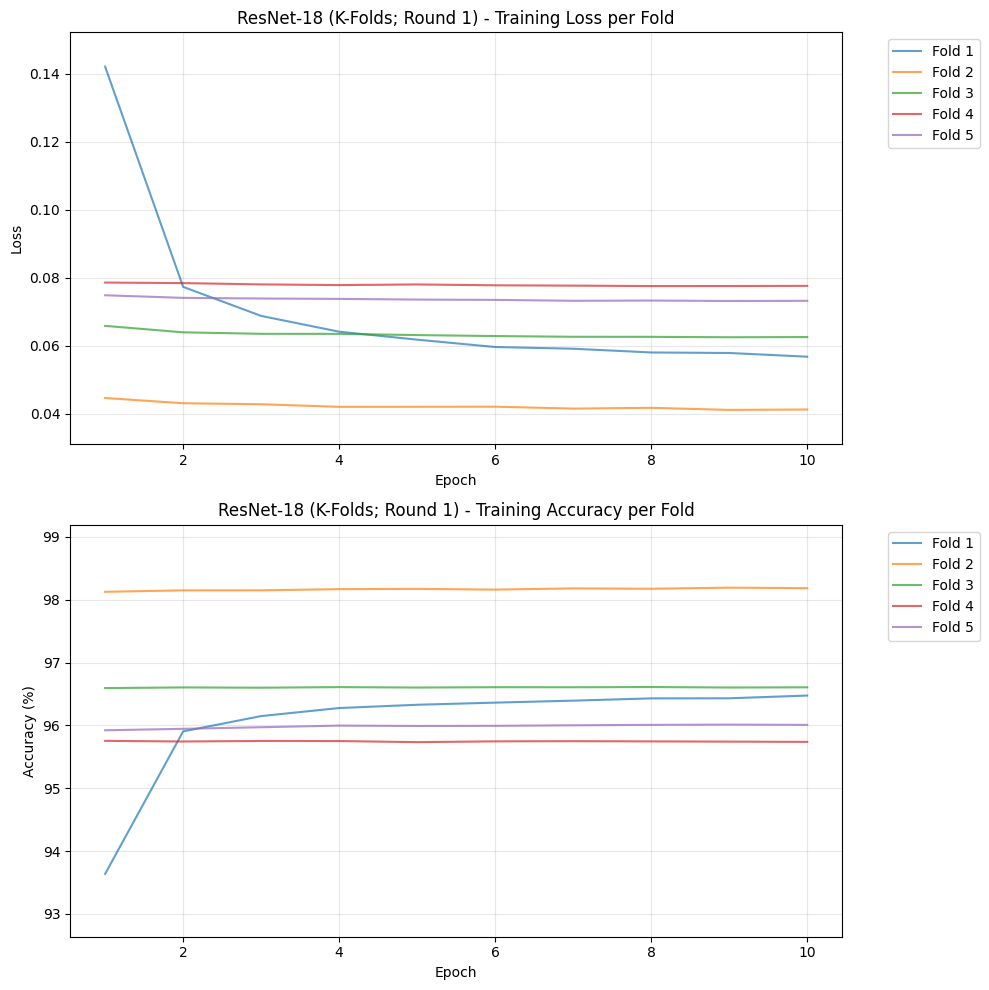

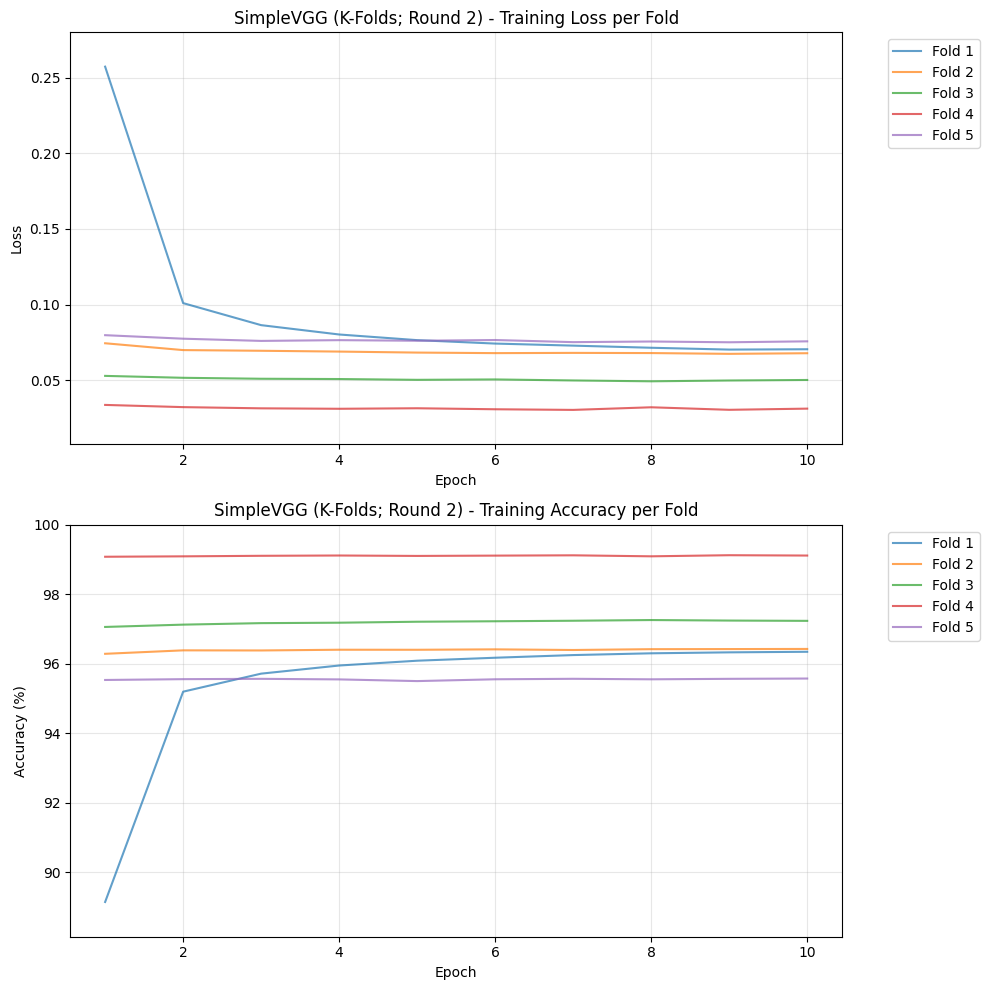

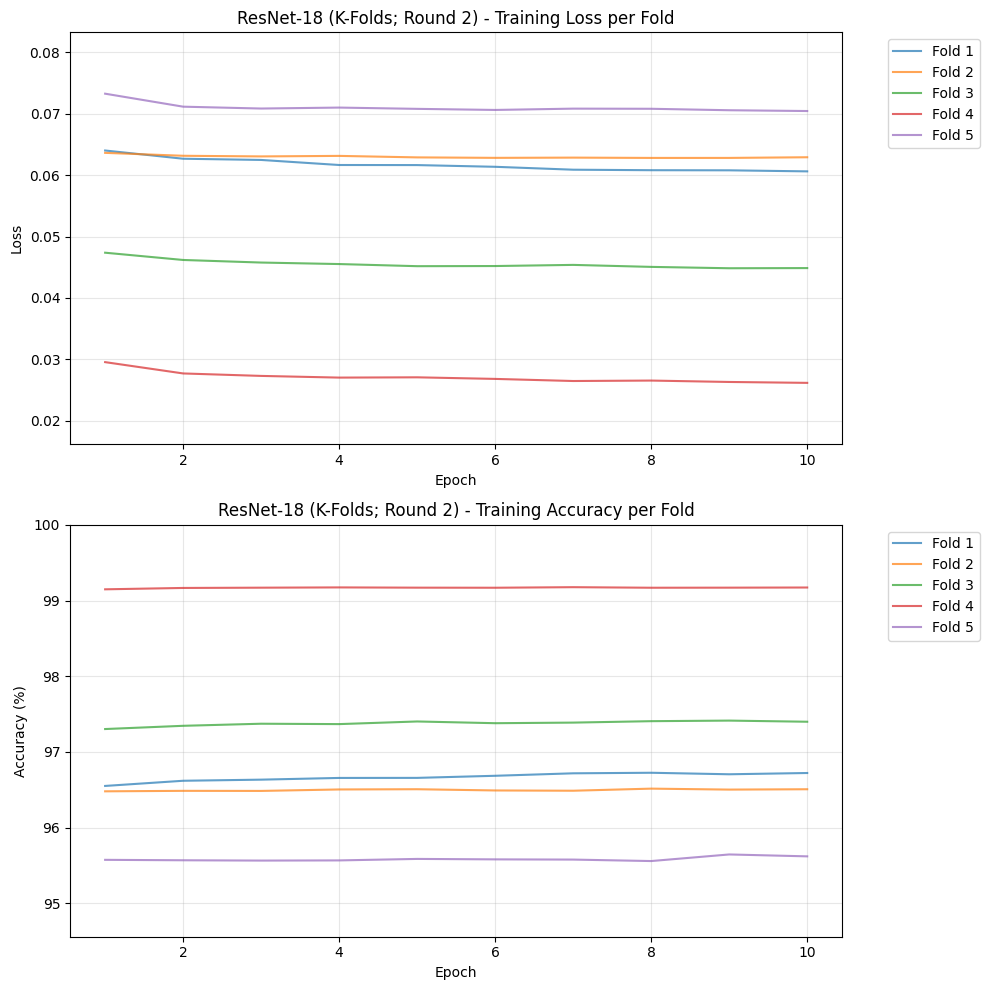

In [114]:
# If you have already run the training and saved the metrics to a .csv file, 
# you can load that file and plot the training curves using the function we defined above.

# available files from repo: 
# kfolds-simpleVGG-model2.csv
# kfolds-simpleVGG-model1.csv
# kfolds-resnet18-model2.csv
# kfolds-resnet18-model1.csv

file_names = [
    "kfolds-simpleVGG-round1.csv",
    "kfolds-resnet18-round1.csv",
    "kfolds-simpleVGG-round2.csv",
    "kfolds-resnet18-round2.csv"
]

for file_name in file_names:
    csv_path = TRAINED_MODELS_RESULTS_DIR / Path(file_name)
    metrics_df = pd.read_csv(csv_path)
    
    round = "Round 1" if "round1" in file_name else "Round 2"
    
    if "simpleVGG" in file_name:
        title_prefix = f"SimpleVGG (K-Folds; {round}) - "
    elif "resnet18" in file_name:
        title_prefix = f"ResNet-18 (K-Folds; {round}) - "
    
    plot_training_metrics(metrics_df, title_prefix=title_prefix)

In [ ]:
# @title Print Summary Results Again (Optional)
# This just prints out the final fold accuracies and mean accuracy 
# for each of the k-folds runs we did

for file_name in file_names:
    csv_path = TRAINED_MODELS_RESULTS_DIR / Path(file_name)
    metrics_df = pd.read_csv(csv_path)
    fold_accuracies = metrics_df.groupby('fold')['val_accuracy'].last().values

    print(f"\n{'='*50}")
    print(file_name.replace(".csv", "").replace("kfolds-", ""))
    print(f"Final Results:")
    print(f"{'='*50}\n")

    print(f"Fold Accuracies:")
    for i, acc in enumerate(fold_accuracies, 1):
        print(f"  Fold {i}: {acc:.2f}%")
            
    print(f"\nMean Accuracy: {np.mean(fold_accuracies):.2f}% (+/- {np.std(fold_accuracies):.2f}%)")
    print(f"{'='*50}")


simpleVGG-round1
Final Results:

Fold Accuracies:
  Fold 1: 95.31%
  Fold 2: 84.82%
  Fold 3: 96.15%
  Fold 4: 99.72%
  Fold 5: 94.99%

Mean Accuracy: 94.20% (+/- 4.98%)

resnet18-round1
Final Results:

Fold Accuracies:
  Fold 1: 96.22%
  Fold 2: 85.68%
  Fold 3: 96.26%
  Fold 4: 99.93%
  Fold 5: 97.39%

Mean Accuracy: 95.10% (+/- 4.90%)

simpleVGG-round2
Final Results:

Fold Accuracies:
  Fold 1: 86.62%
  Fold 2: 96.50%
  Fold 3: 80.73%
  Fold 4: 85.90%
  Fold 5: 95.97%

Mean Accuracy: 89.14% (+/- 6.14%)

resnet18-round2
Final Results:

Fold Accuracies:
  Fold 1: 92.69%
  Fold 2: 96.69%
  Fold 3: 80.48%
  Fold 4: 86.10%
  Fold 5: 98.74%

Mean Accuracy: 90.94% (+/- 6.78%)


---

&nbsp;

## Extra Functions For Further Analysis (All Optional)

All code below is purely optional and largely meant for data generation / exploration. 

Audio_To_Spectrogram_Processor was used to generate new mel-spectrograms for the clean, pre-processed audio recordings provided by the dataset. It goes through and processes the audio by making any specified modifications to the recording itself, and generates the new mel-specs from that.

From there the next cell runs the code and then properly stores it in our original mel-specs folder that we downloaded. 

visualize_predictions() is for generating a random test set of mel-specs and then graphing them to see what they look like, as well as how the currently loaded model classified them. Note that it partially relies on the code used for running a single loop of training (i.e., the cell that contains 'test_dataset')

The final code cell is for generating a sample dataset that can be uploaded to github, given the file size restrictions. 

In [ ]:
# @title Data Loader Class for Generating Mel-Spectrograms
# Specifically designed for batch processing of Clean_Recordings folders.

class Audio_To_Spectrogram_Processor:

    def __init__(self,
                 target_sample_rate=SAMPLE_RATE,  # Sample rate to resample to
                 num_samples=SAMPLE_RATE * 2):    # Number of samples to normalize audio to

        self.target_sample_rate = target_sample_rate
        self.num_samples = num_samples

        # Setup mel spectrogram transform to match datasets format
        # 128 frequency bands, window length 1024, hop size 512
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.target_sample_rate,
            n_mels=N_MELS,
            n_fft=WINDOW_LENGTH,
            hop_length=HOP_SIZE)

    """HELPER FUNCTIONS FOR PREPROCESSING"""

    def _resample_if_necessary(self, signal, sr):
        """Resample signal to target sample rate if necessary."""

        if sr != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(sr, self.target_sample_rate)
            signal = resampler(signal)
        return signal

    def _mix_down_if_necessary(self, signal):
        """Convert multi-channel signal to mono if necessary."""

        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_if_necessary(self, signal):
        """Trim signal if it's longer than num_samples."""

        if signal.shape[1] > self.num_samples:
            signal = signal[:, :self.num_samples]
        return signal

    def _right_pad_if_necessary(self, signal):
        """Pad signal with zeros if it's shorter than num_samples."""

        length_signal = signal.shape[1]
        if length_signal < self.num_samples:
            num_missing_samples = self.num_samples - length_signal
            last_dim_padding = (0, num_missing_samples)
            signal = torch.nn.functional.pad(signal, last_dim_padding)
        return signal

    # Main function to process a single audio file and return mel spectrogram
    # Returns: 2D numpy array (freq_bins x time_frames) or None if error
    def process_audio_file(self,
                           wav_file_path):

        try:
            # Load audio file
            waveform, sr = librosa.load(wav_file_path, sr=self.target_sample_rate)
            waveform = torch.tensor(waveform).unsqueeze(0)

            # Apply preprocessing steps
            waveform = self._resample_if_necessary(waveform, sr)
            waveform = self._mix_down_if_necessary(waveform)
            waveform = self._cut_if_necessary(waveform)
            waveform = self._right_pad_if_necessary(waveform)

            # Generate mel spectrogram
            mel_spec = self.mel_transform(waveform)

            # Convert to numpy and squeeze to 2D (freq_bins, time_frames)
            mel_spec_np = mel_spec.squeeze(0).numpy().astype(np.float32)

            return mel_spec_np

        except Exception as e:
            print(f"Error processing {wav_file_path.name}: {e}")
            return None

    # returns count of successfully processed files
    def process_folder(self,
                       input_dir,           # Path to folder containing WAV files
                       output_dir,          # Path to folder where NPY files will be saved
                       audio_type_name):    # Name for logging (e.g., "Mono (No FX)")

        if not input_dir.exists():
            print(f"Warning: {input_dir} does not exist. Skipping {audio_type_name}.")
            return 0

        skipped = 0
        successful = 0
        wav_files = list(input_dir.glob("*.wav"))

        print(f"\n=== Processing {audio_type_name} ===")
        print(f"Found {len(wav_files)} WAV files")

        for wav_file in tqdm(wav_files, desc=f"Processing {audio_type_name}", unit="file"):
            mel_spec_np = self.process_audio_file(wav_file)

            if mel_spec_np is not None:
                # Save as NPY file with same name as WAV
                output_file = output_dir / wav_file.stem
                np.save(str(output_file), mel_spec_np)
                successful += 1
            else:
                skipped += 1

        print(f"Completed {audio_type_name}: {successful} successful, {skipped} skipped")
        return successful


In [ ]:
# @title Generate Mel-Spectrograms from Clean Recordings

# Initialize the audio processor
audio_processor = Audio_To_Spectrogram_Processor()

# Setup paths
mono_input_dir = Path(DATASETS_DIR) / "Clean_Recordings" / "_NoFX_mono_preprocessed"
poly_input_dir = Path(DATASETS_DIR) / "Clean_Recordings" / "_NoFX_poly_preprocessed"

# Output directories
output_base_dir = Path(MEL_SPECTROGRAMS_DIR) / "Clean"
mono_output_dir = output_base_dir / "Mono_Clean"
poly_output_dir = output_base_dir / "Poly_Clean"

# Create output directories if they don't exist
mono_output_dir.mkdir(parents=True, exist_ok=True)
poly_output_dir.mkdir(parents=True, exist_ok=True)

# Process recordings
mono_count = audio_processor.process_folder(mono_input_dir, mono_output_dir, "Mono_Clean")
poly_count = audio_processor.process_folder(poly_input_dir, poly_output_dir, "Poly_Clean")

print(f"\n{'='*50}")
print(f"Mel Spectrogram Generation Complete!")
print(f"{'='*50}")
print(f"Total Mono Specs Generated: {mono_count}")
print(f"Total Poly Specs Generated: {poly_count}")
print(f"Output Location: {output_base_dir}")

In [45]:
# @title Visualizing Model Predictions (Optional)

# Create reverse mapping from index to label
idx_to_label = {v: k for k, v in label_to_idx.items()}

# This function takes random test samples and then plots the mel-spectrograms
# Above the graphs are the labels for classification and what the model predicted
# (Red indiciates incorrect; Green indiciates correct)
def visualize_predictions(model, test_dataset, device, num_samples=4):

    # Calculate grid dimensions dynamically
    cols = min(2, num_samples)  # Default to 2 columns, or fewer if num_samples < 2
    rows = math.ceil(num_samples / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))

    # Handle case where there's only 1 subplot (axes won't be an array)
    if num_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    model.eval()

    # Get random training indices
    random_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    with torch.no_grad():
        for idx, data_idx in enumerate(random_indices):
            # Get sample
            mel_spec, true_label = test_dataset[data_idx]

            # Add batch dimension (i.e. shape becomes [1, 128, time_frames])
            mel_spec_batch = mel_spec.unsqueeze(0).to(device)

            # Get prediction
            output = model(mel_spec_batch)
            _, predicted_label = torch.max(output, 1)

            predicted_label_indices = predicted_label.item()
            true_label_indices = true_label.item()

            # Convert indices to class names (with bounds checking)
            true_class = idx_to_label.get(true_label_indices, f"Unknown ({true_label_indices})")
            predicted_class = idx_to_label.get(predicted_label_indices, f"Unknown ({predicted_label_indices})")

            # Plot spectrogram using librosa (remove channel dimension and convert to numpy)
            mel_np = mel_spec.squeeze(0).cpu().numpy()

            # Display mel-spectrogram with proper frequency and time axes
            im = librosa.display.specshow(
                mel_np,
                sr=SAMPLE_RATE,
                hop_length=HOP_SIZE,
                x_axis='time',
                y_axis='mel',
                ax=axes[idx],
                cmap='viridis' # viridis, plasma, inferno, magma are good options for mel-specs
            )

            # Color the title based on correctness
            is_correct = (true_label_indices == predicted_label_indices)
            title_color = 'green' if is_correct else 'red'

            axes[idx].set_title(
                f"True: {true_class}\nPredicted: {predicted_class}",
                fontsize=12,
                color=title_color,
                fontweight='bold'
            )

            # Add colorbar for illustrating intensity of mel spectrogram (in decibels)
            cbar = fig.colorbar(im, ax=axes[idx], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

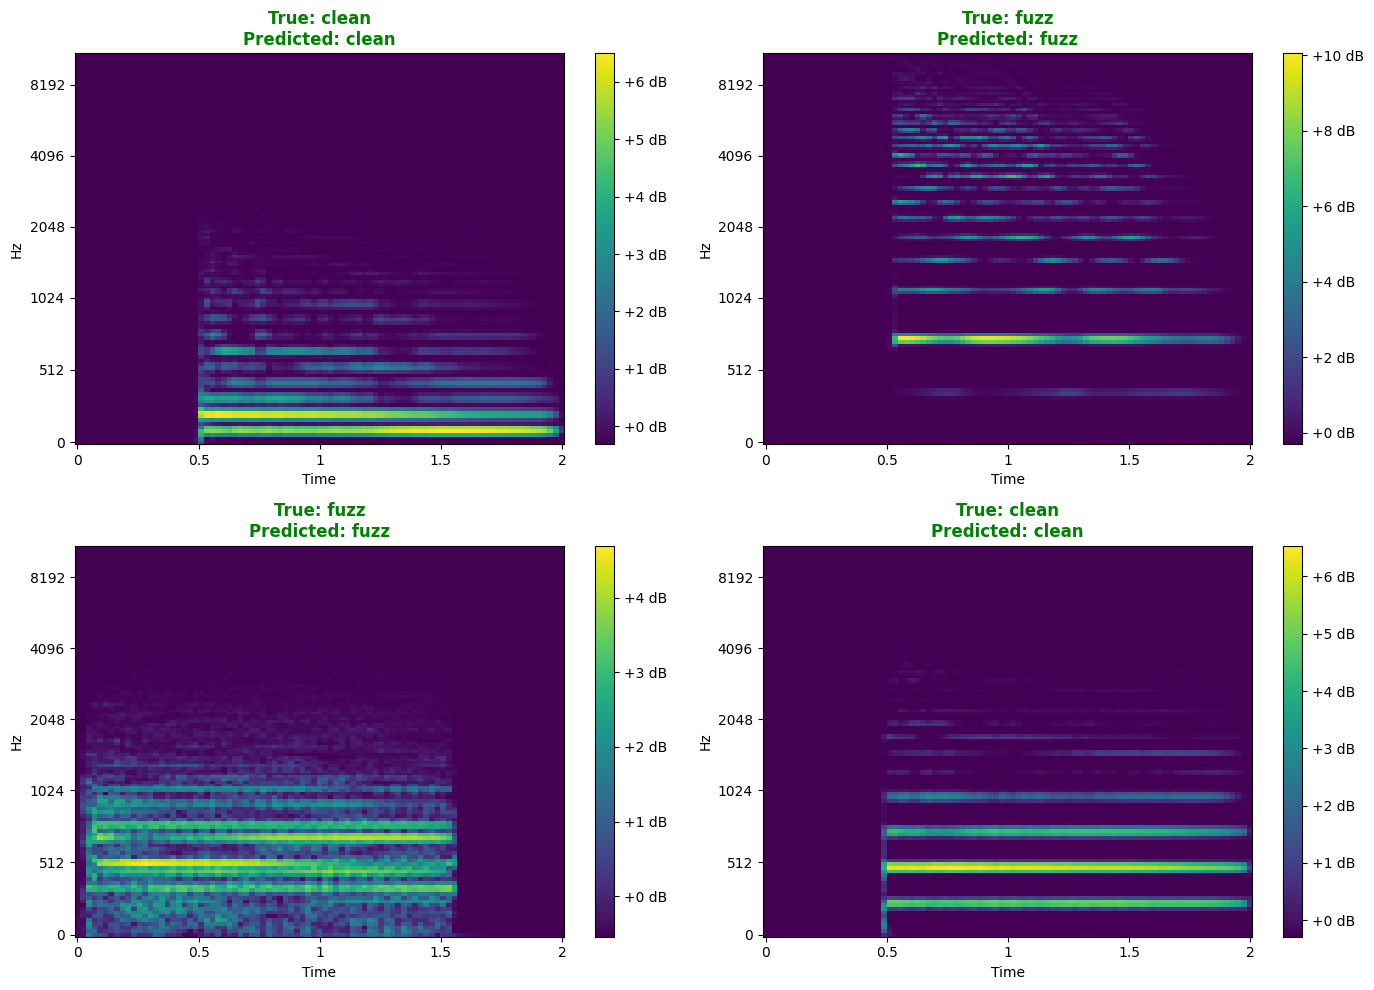

In [110]:
# @title Looking at Mel-spectrograms and Predictions
visualize_predictions(MODEL, test_dataset, DEVICE, num_samples=4)

In [68]:
# @title Create minimal sample dataset (optional)
# Saves to Downloads/Guitar_FX_Classification_Project
DOWNLOADS_DIR = Path.home() / "Downloads" / "Guitar_FX_Classification_Project"
SAMPLE_OUTPUT_DIR = DOWNLOADS_DIR / "hdf5_shards"

# delete existing sample directory if it exists 
if DOWNLOADS_DIR.exists():
    shutil.rmtree(DOWNLOADS_DIR)
DOWNLOADS_DIR.mkdir(parents=True, exist_ok=True)

# Define sampling pattern: each category gets 1 shard 
# number indicates how many samples to take from the original shard
num_samples = 40
categories_mini = {
    "Mono_Clean": {
        "clean": num_samples  
    },
    "Mono_Continuous": {
        "distortion": num_samples,
        "fuzz": num_samples,
        "overdrive": num_samples,
    },
    "Mono_Discrete": {
        "distortion": num_samples,
        "fuzz": num_samples,
        "overdrive": num_samples,
    },
    "Poly_Clean": {
        "clean": num_samples
    },
    "Poly_Continuous": {
        "distortion": num_samples,
        "fuzz": num_samples,
        "overdrive": num_samples,
    },
    "Poly_Discrete": {
        "distortion": num_samples,
        "fuzz": num_samples,
        "overdrive": num_samples,
    },
}

# Track which files to include in the filtered metadata CSV
filtered_rows = []

# Process each category and create mini shards
for category, effects_dict in categories_mini.items():
    category_dir = SAMPLE_OUTPUT_DIR / category
    category_dir.mkdir(parents=True, exist_ok=True)
    
    for effect_type, num_samples in effects_dict.items():
        # Find the source shard file(s) from the original dataset
        source_shards = list((BASE_SHARDS_DIR / category).glob(f"{category}_{effect_type}_shard_*.h5"))
        
        if not source_shards:
            print(f"No shards found for {category}/{effect_type}")
            continue
        
        # Use the first shard as source
        source_file = source_shards[0]
        
        try:
            # Load samples from source shard
            with h5py.File(source_file, 'r') as src_f:
                total_samples = len(src_f['mel'])
                samples_to_take = min(num_samples, total_samples)
                
                mel_data = src_f['mel'][:samples_to_take]
                label_data = src_f['label'][:samples_to_take]
            
            # Create new mini shard
            output_file = category_dir / f"{category}_{effect_type}_shard_000.h5"
            with h5py.File(output_file, 'w') as dst_f:
                dst_f.create_dataset('mel', data=mel_data, dtype='float32')
                dst_f.create_dataset('label', data=label_data, dtype='int64')
            
            file_size_mb = output_file.stat().st_size / (1024 * 1024)
            print(f"Created {category}/{effect_type} ({samples_to_take} samples, {file_size_mb:.2f} MB)")
            
            # Get rows from original dataframe that match this category and effect
            if category in df_audio_dict:
                category_df = df_audio_dict[category]
                matching_rows = category_df[category_df['fx'] == effect_type].head(samples_to_take)
                filtered_rows.append(matching_rows)
            
        except Exception as e:
            print(f"Error processing {category}/{effect_type}: {e}")

# Create filtered metadata CSV
filtered_metadata_df = pd.concat(filtered_rows, ignore_index=True)
metadata_output_path = DOWNLOADS_DIR / "merged_metadata.csv"
filtered_metadata_df.to_csv(metadata_output_path, index=False)

print(f"\n{'='*50}")
print(f"Mini Sample Dataset Created Successfully!")
print(f"{'='*50}")
print(f"Location: {DOWNLOADS_DIR}")

# Calculate total size
total_size = sum(f.stat().st_size for f in SAMPLE_OUTPUT_DIR.rglob('*.h5')) / (1024 * 1024)
print(f"Total Dataset Size: {total_size:.2f} MB")
print(f"Metadata Rows: {len(filtered_metadata_df)}")

print(f"\nDirectory structure created:")
for category in categories_mini.keys():
    effect_count = len(categories_mini[category])
    print(f"  {category}/ ({effect_count} effect types)")

Created Mono_Clean/clean (40 samples, 1.70 MB)
Created Mono_Continuous/distortion (40 samples, 1.70 MB)
Created Mono_Continuous/fuzz (40 samples, 1.70 MB)
Created Mono_Continuous/overdrive (40 samples, 1.70 MB)
Created Mono_Discrete/distortion (40 samples, 1.70 MB)
Created Mono_Discrete/fuzz (40 samples, 1.70 MB)
Created Mono_Discrete/overdrive (40 samples, 1.70 MB)
Created Poly_Clean/clean (40 samples, 1.70 MB)
Created Poly_Continuous/distortion (40 samples, 1.70 MB)
Created Poly_Continuous/fuzz (40 samples, 1.70 MB)
Created Poly_Continuous/overdrive (40 samples, 1.70 MB)
Created Poly_Discrete/distortion (40 samples, 1.70 MB)
Created Poly_Discrete/fuzz (40 samples, 1.70 MB)
Created Poly_Discrete/overdrive (40 samples, 1.70 MB)

Mini Sample Dataset Created Successfully!
Location: C:\Users\Proff\Downloads\Guitar_FX_Classification_Project
Total Dataset Size: 23.82 MB
Metadata Rows: 560

Directory structure created:
  Mono_Clean/ (1 effect types)
  Mono_Continuous/ (3 effect types)
  Mono